In [52]:
import numpy as np


def dagostini_unfold(
    data,
    response,
    prior=None,
    max_iter=50,
    tol=1e-4,
    min_iter=2,
    smoothing=None,
    verbose=True
):
    """
    D’Agostini iterative Bayesian unfolding
    with early stopping.

    Parameters
    ----------

    data :
        reco data counts (N_reco)

    response :
        response matrix R[reco, truth]

    prior :
        initial truth guess

    tol :
        early stopping tolerance.

    smoothing :
        optional function(truth)->truth

    """

    data = np.asarray(data)

    R = np.asarray(response)

    ntruth = R.shape[1]

    if prior is None:
        prior = np.ones(ntruth)

    T = prior.astype(float)
    T /= T.sum()

    history = []

    for k in range(max_iter):

        # -------- forward fold prediction

        reco_pred = R @ T

        # avoid divide by zero
        reco_pred = np.clip(reco_pred, 1e-12, None)

        # -------- correction factor

        ratio = data / reco_pred

        # -------- back projection

        correction = R.T @ ratio

        T_new = T * correction

        # normalize
        T_new /= T_new.sum()

        # -------- optional smoothing
        if smoothing is not None:
            T_new = smoothing(T_new)

        # -------- early stopping

        diff = np.linalg.norm(T_new - T)

        history.append(diff)

        if verbose:
            print(f"iter {k} diff = {diff:.3e}")

        if k > min_iter and diff < tol:
            print(f"Early stopping at iter {k}")
            break

        T = T_new

    return T, history

(80, 40)


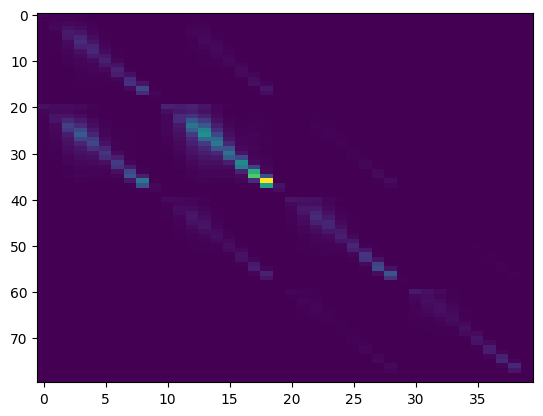

In [53]:
#load response from outputs/unfolding_mosaic.npz
response_matrix = np.load("/home/aritra/ws/unfold/outputs/unfolding_mosaic.npz")["mosaic"]
import matplotlib.pyplot as plt
print(response_matrix.shape)
plt.imshow(response_matrix, aspect="auto");
data = response_matrix.sum(axis = 1)
prior = response_matrix.sum(axis = 0)

#normalize mosaic 
response_matrix /= response_matrix.sum(axis = 0, keepdims=True)

data_2 = np.load("/home/aritra/ws/unfold/outputs/unfolding_mosaic_2d.npz")["mosaic_2d"]


In [58]:
truth, hist = dagostini_unfold(
    data = data_2,
    response = response_matrix,
    prior = prior,
    tol = 0.0001
)

iter 0 diff = 1.889e-02
iter 1 diff = 7.823e-03
iter 2 diff = 4.509e-03
iter 3 diff = 2.888e-03
iter 4 diff = 1.987e-03
iter 5 diff = 1.458e-03
iter 6 diff = 1.131e-03
iter 7 diff = 9.138e-04
iter 8 diff = 7.604e-04
iter 9 diff = 6.460e-04
iter 10 diff = 5.570e-04
iter 11 diff = 4.856e-04
iter 12 diff = 4.271e-04
iter 13 diff = 3.785e-04
iter 14 diff = 3.374e-04
iter 15 diff = 3.026e-04
iter 16 diff = 2.726e-04
iter 17 diff = 2.468e-04
iter 18 diff = 2.244e-04
iter 19 diff = 2.049e-04
iter 20 diff = 1.879e-04
iter 21 diff = 1.729e-04
iter 22 diff = 1.598e-04
iter 23 diff = 1.481e-04
iter 24 diff = 1.378e-04
iter 25 diff = 1.287e-04
iter 26 diff = 1.206e-04
iter 27 diff = 1.134e-04
iter 28 diff = 1.069e-04
iter 29 diff = 1.011e-04
iter 30 diff = 9.591e-05
Early stopping at iter 30


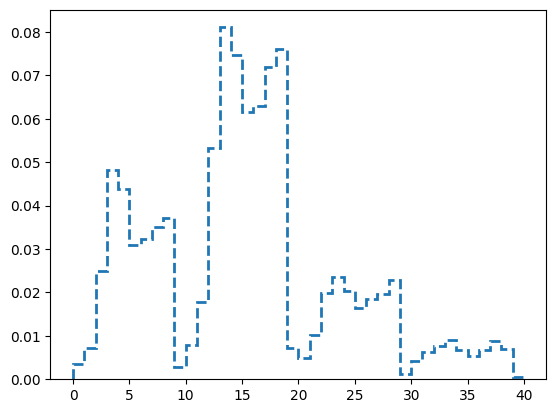

In [59]:
plt.stairs(truth, lw = 2, ls = "--")
#plt.stairs(prior, alpha=0.5)

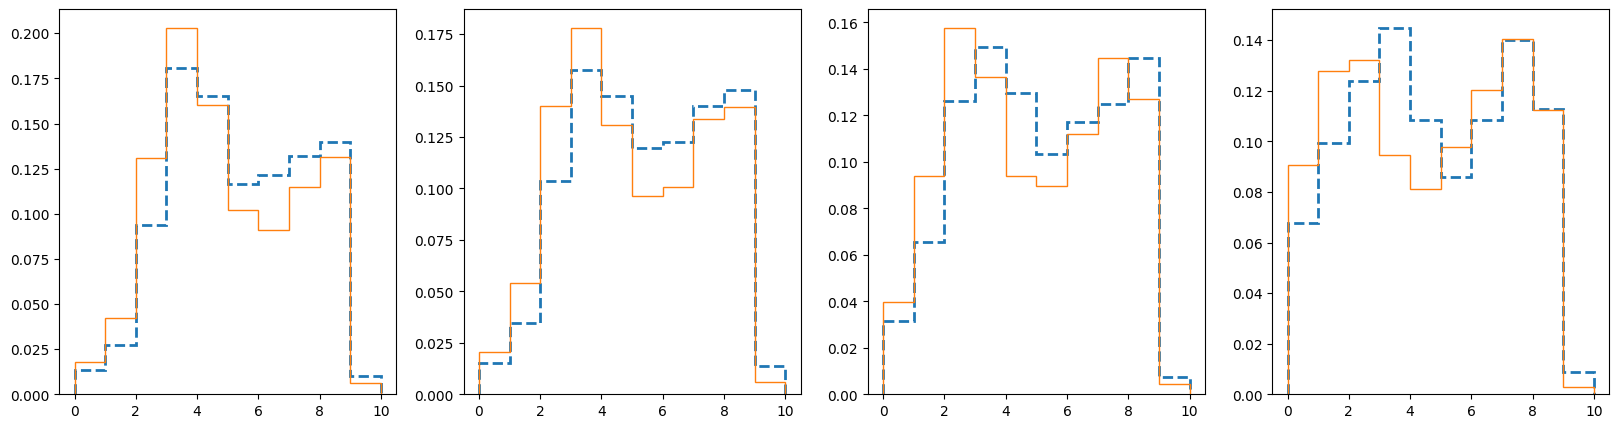

In [60]:
plt.figure(figsize=(20, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    unfolded = truth[i*10:(i+1)*10]
    theory = prior[i*10:(i+1)*10]
    unfolded = unfolded / unfolded.sum()
    theory = theory / theory.sum()
    plt.stairs(unfolded, label=f"unfolded {i}", lw = 2, ls = "--")
    plt.stairs(theory, label=f"theory {i}")
